<a href="https://colab.research.google.com/github/DhanushReddymittapalli/DhanushReddymittapalli/blob/main/FinGuard-AI-Research/notebooks/FinGuard_XAI_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap xgboost pandas scikit-learn matplotlib -q

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'creditcard.csv (2).zip', 'sample_data']


In [ ]:
import glob

files = glob.glob("/content/*")
print(files)

['/content/creditcard.csv (2).zip', '/content/sample_data']


In [ ]:
import glob
import os

f = glob.glob("/content/*.zip")[0]

print("File:", f)
print("Size:", os.path.getsize(f), "bytes")

!file "$f"

File: /content/creditcard.csv (2).zip
Size: 10485760 bytes
/content/creditcard.csv (2).zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [ ]:
import os
import glob

files = glob.glob("/content/*")
for f in files:
    print(f, os.path.getsize(f))

/content/creditcard.csv.zip 19922944
/content/sample_data 4096


In [ ]:
import os

f = "/content/creditcard.csv.zip"

size_mb = os.path.getsize(f) / (1024 * 1024)

print("File size:", round(size_mb, 2), "MB")

File size: 19.0 MB


In [ ]:
import glob
import os

for f in glob.glob("/content/*.zip"):
    print("FOUND:", f)
    print("SIZE:", round(os.path.getsize(f)/(1024*1024), 2), "MB")

FOUND: /content/creditcard.csv (1).zip
SIZE: 1.0 MB


In [ ]:
import glob
import os

for f in glob.glob("/content/*.zip"):
    print(f, round(os.path.getsize(f)/(1024*1024), 2), "MB")

/content/creditcard.csv (1).zip 27.0 MB


In [ ]:

import zipfile
import glob
import os

zip_path = "/content/creditcard.csv (1).zip"

print("Size:", round(os.path.getsize(zip_path)/(1024*1024), 2), "MB")

with zipfile.ZipFile(zip_path, "r") as z:
    print("Files inside:", z.namelist())
    bad = z.testzip()

print("ZIP check:", "OK ✅" if bad is None else f"CORRUPTED ❌: {bad}")

Size: 80.9 MB
Files inside: ['creditcard.csv']
ZIP check: CORRUPTED ❌: creditcard.csv


In [ ]:
!pip -q install kagglehub

import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Downloaded to:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Downloaded to: /kaggle/input/creditcardfraud


In [ ]:
import os

print("Downloaded files:")

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Downloaded files:
/kaggle/input/creditcardfraud/creditcard.csv


In [ ]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/creditcardfraud/creditcard.csv


In [ ]:
import pandas as pd

csv_path = "/kaggle/input/creditcardfraud/creditcard.csv"

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())

Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (227845, 30)
Testing: (56962, 30)


In [ ]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

print("XGBoost training completed ✅")

XGBoost training completed ✅


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("ROC-AUC :", round(roc_auc_score(y_test, y_prob), 4))
print("PR-AUC  :", round(average_precision_score(y_test, y_prob), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))

ROC-AUC : 0.9816
PR-AUC  : 0.8565
Precision: 0.6614
Recall   : 0.8571
F1-score : 0.7467


In [ ]:
[k for k in globals() if "xgb" in k.lower()]

['XGBClassifier']

In [ ]:
import shap

# Train XGBoost again and save it as xgb_model
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost model ready ✅")

XGBoost model ready ✅


In [ ]:

# Select 1000 test samples for SHAP
X_shap = X_test.sample(1000, random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP analysis completed ✅")
print("Samples analyzed:", len(X_shap))
print("Features analyzed:", X_shap.shape[1])

SHAP analysis completed ✅
Samples analyzed: 1000
Features analyzed: 30


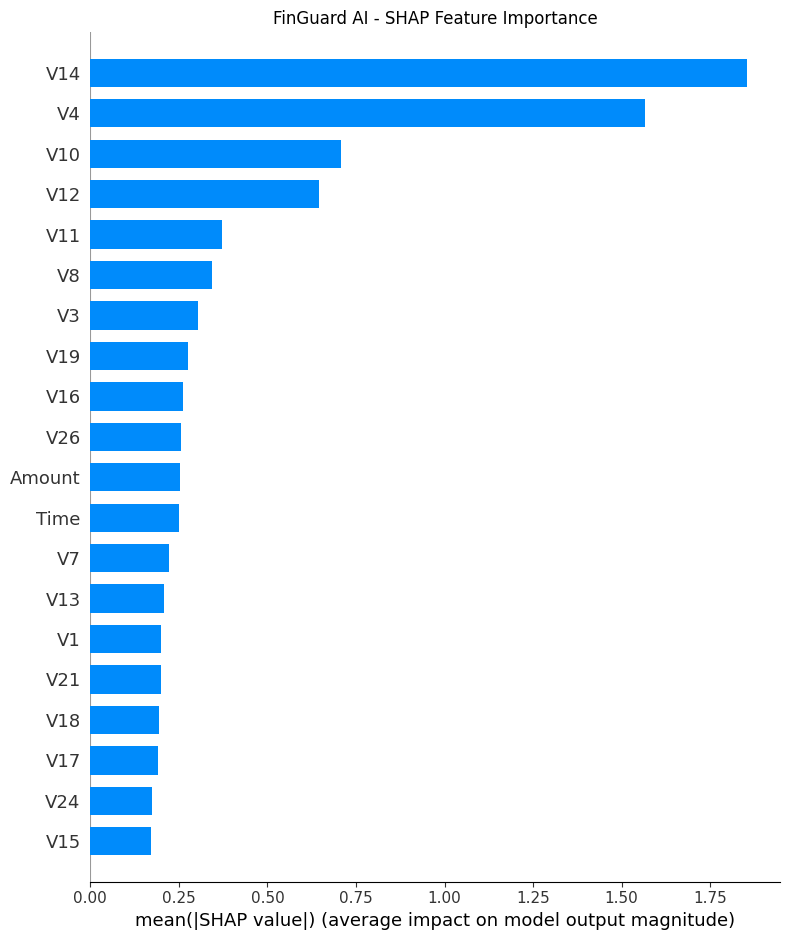

SHAP feature importance graph saved ✅


In [ ]:
import matplotlib.pyplot as plt

# SHAP feature importance
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title("FinGuard AI - SHAP Feature Importance")
plt.tight_layout()
plt.savefig("FinGuard_shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print("SHAP feature importance graph saved ✅")

In [ ]:
import pandas as pd
import numpy as np

# Calculate mean absolute SHAP importance
shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

# Sort from most important to least important
shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

# Save results
shap_importance.to_csv(
    "FinGuard_shap_feature_importance.csv",
    index=False
)

print("SHAP numerical results saved ✅")
print(shap_importance.head(10))

SHAP numerical results saved ✅
   Feature  Mean_Absolute_SHAP
14     V14            1.854592
4       V4            1.567190
10     V10            0.707574
12     V12            0.645627
11     V11            0.371311
8       V8            0.342634
3       V3            0.304112
19     V19            0.274575
16     V16            0.260288
26     V26            0.255544


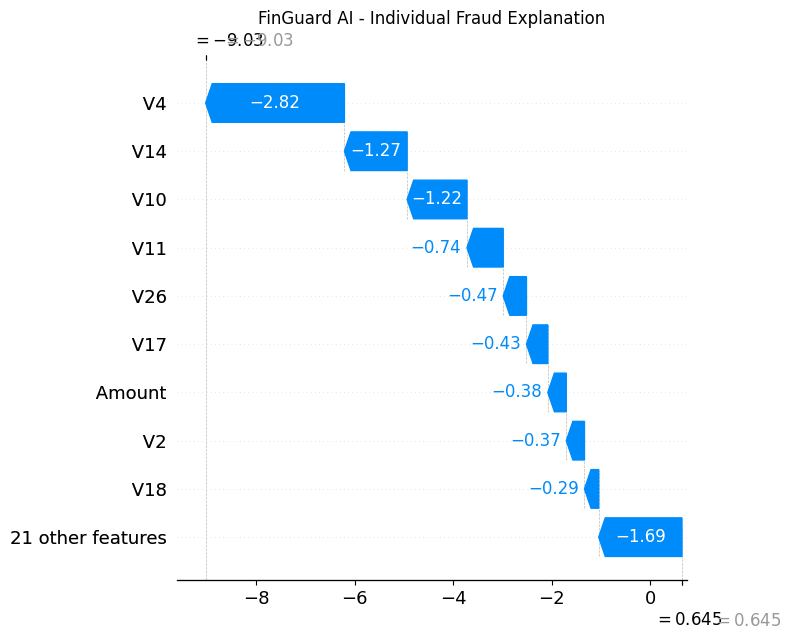

Individual SHAP explanation saved ✅


In [ ]:
# Explain one transaction using SHAP

import numpy as np
import matplotlib.pyplot as plt

# Select one test transaction
transaction = X_test.iloc[[0]]

# Calculate SHAP values for this transaction
transaction_shap = explainer.shap_values(transaction)

# SHAP waterfall explanation
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    transaction_shap[0],
    transaction.iloc[0],
    feature_names=transaction.columns,
    show=False
)

plt.title("FinGuard AI - Individual Fraud Explanation")
plt.tight_layout()

plt.savefig(
    "FinGuard_individual_explanation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Individual SHAP explanation saved ✅")

In [ ]:
from google.colab import files

files.download("FinGuard_shap_feature_importance.csv")
files.download("FinGuard_shap_feature_importance.png")
files.download("FinGuard_individual_explanation.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import os

files = [
    "/content/FinGuard_shap_feature_importance.csv",
    "/content/FinGuard_shap_feature_importance.png",
    "/content/FinGuard_individual_explanation.png",
    "/content/FinGuard_error_analysis.csv",
    "/content/FinGuard_threshold_analysis.csv",
    "/content/FinGuard_threshold_tradeoff.png",
    "/content/FinGuard_model_comparison_results.csv",
    "/content/FinGuard_model_comparison.png"
]

for f in files:
    print("✅" if os.path.exists(f) else "❌", f)

✅ /content/FinGuard_shap_feature_importance.csv
✅ /content/FinGuard_shap_feature_importance.png
✅ /content/FinGuard_individual_explanation.png
✅ /content/FinGuard_error_analysis.csv
❌ /content/FinGuard_threshold_analysis.csv
❌ /content/FinGuard_threshold_tradeoff.png
✅ /content/FinGuard_model_comparison_results.csv
❌ /content/FinGuard_model_comparison.png


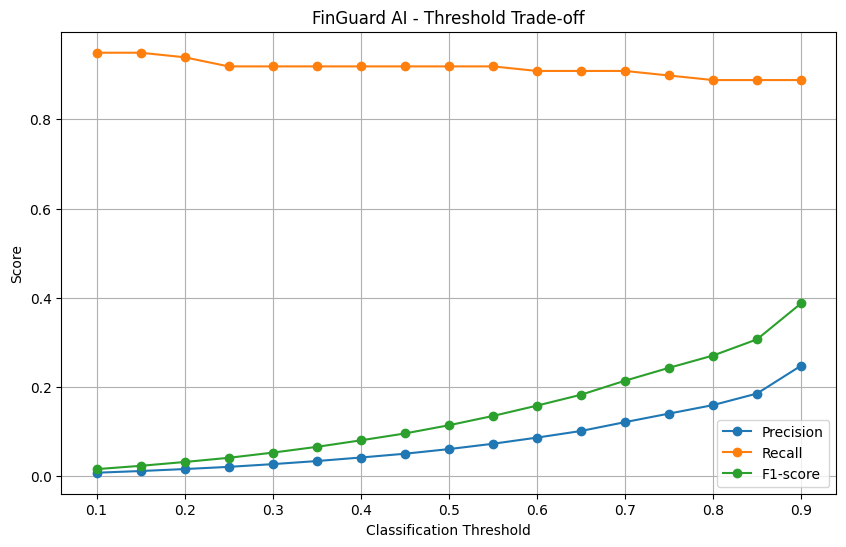

✅ Threshold analysis created
✅ FinGuard_threshold_analysis.csv
✅ FinGuard_threshold_tradeoff.png


In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results.to_csv(
    "FinGuard_threshold_analysis.csv",
    index=False
)

plt.figure(figsize=(10, 6))
plt.plot(threshold_results["Threshold"], threshold_results["Precision"], marker="o", label="Precision")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], marker="o", label="Recall")
plt.plot(threshold_results["Threshold"], threshold_results["F1"], marker="o", label="F1-score")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("FinGuard AI - Threshold Trade-off")
plt.legend()
plt.grid(True)

plt.savefig(
    "FinGuard_threshold_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Threshold analysis created")
print("✅ FinGuard_threshold_analysis.csv")
print("✅ FinGuard_threshold_tradeoff.png")

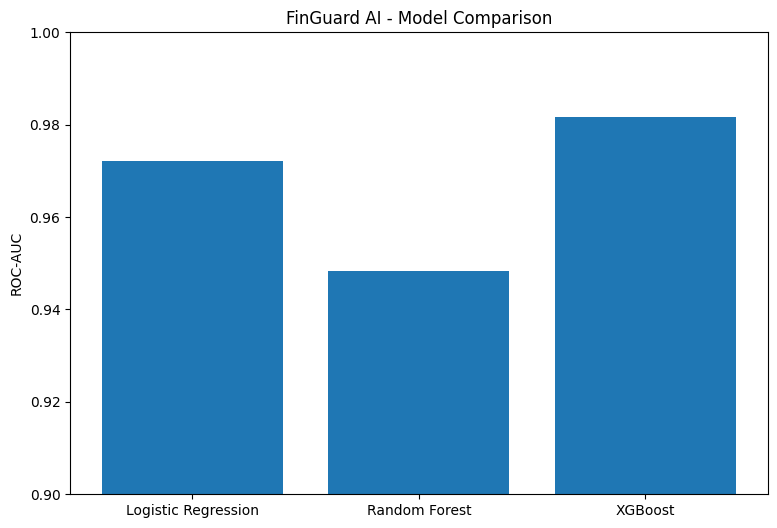

✅ FinGuard_model_comparison.png created


In [25]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest", "XGBoost"]
roc_auc = [0.9721, 0.9483, 0.9816]

plt.figure(figsize=(9, 6))
plt.bar(models, roc_auc)

plt.ylabel("ROC-AUC")
plt.title("FinGuard AI - Model Comparison")
plt.ylim(0.90, 1.00)

plt.savefig(
    "FinGuard_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ FinGuard_model_comparison.png created")

In [27]:
from google.colab import files

files.download("FinGuard_shap_feature_importance.csv")
files.download("FinGuard_shap_feature_importance.png")
files.download("FinGuard_individual_explanation.png")
files.download("FinGuard_error_analysis.csv")
files.download("FinGuard_threshold_analysis.csv")
files.download("FinGuard_threshold_tradeoff.png")
files.download("FinGuard_model_comparison_results.csv")
files.download("FinGuard_model_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>